In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [10]:
import pandas as pd
df = pd.read_csv("/content/genz-smusage-10ksample.csv", header=1)
df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [11]:
df.columns.tolist()

['age',
 'gender',
 'country',
 'daily_usage_hours',
 'primary_platform',
 'num_platforms_used',
 'purpose',
 'avg_session_minutes',
 'night_usage',
 'mental_health_score',
 'addiction_level',
 'screen_time_before_sleep']

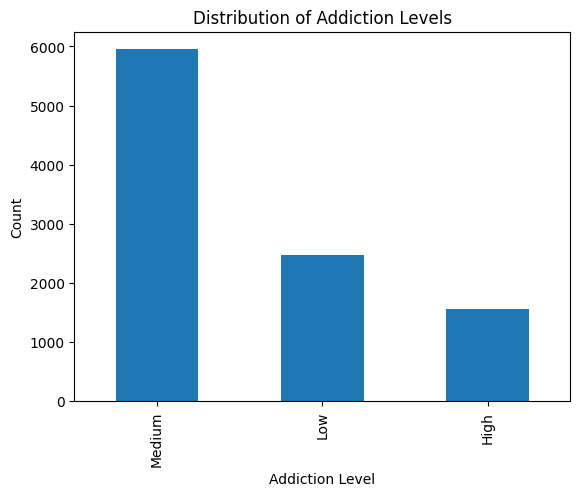

In [12]:
import matplotlib.pyplot as plt

df["addiction_level"].value_counts().plot(kind="bar")

plt.title("Distribution of Addiction Levels")
plt.xlabel("Addiction Level")
plt.ylabel("Count")
plt.show()

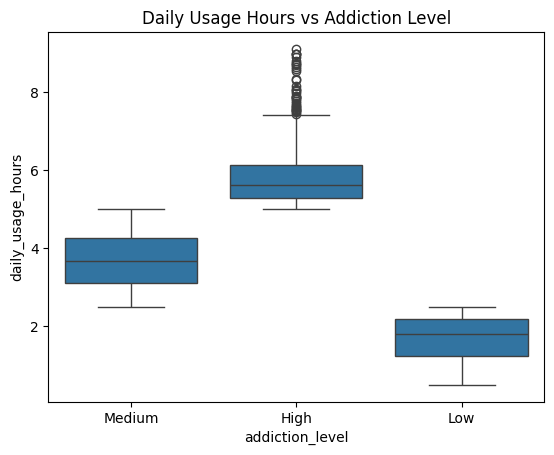

In [13]:
import seaborn as sns

sns.boxplot(x="addiction_level", y="daily_usage_hours", data=df)

plt.title("Daily Usage Hours vs Addiction Level")
plt.show()

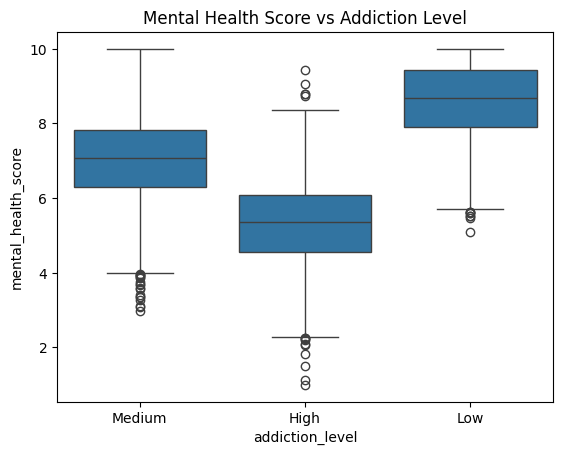

In [14]:
sns.boxplot(x="addiction_level", y="mental_health_score", data=df)

plt.title("Mental Health Score vs Addiction Level")
plt.show()

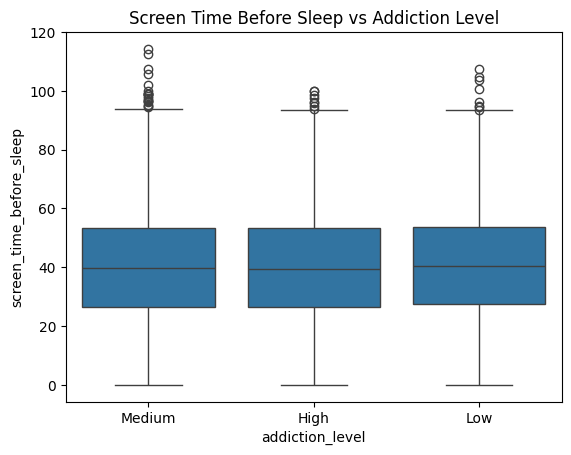

In [15]:
sns.boxplot(x="addiction_level", y="screen_time_before_sleep", data=df)

plt.title("Screen Time Before Sleep vs Addiction Level")
plt.show()

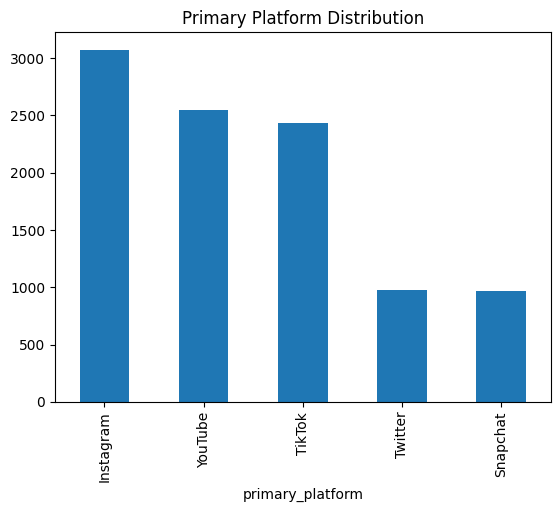

In [16]:
df["primary_platform"].value_counts().plot(kind="bar")

plt.title("Primary Platform Distribution")
plt.show()

In [17]:
df["addiction_level"] = df["addiction_level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

In [18]:
df = pd.get_dummies(df, columns=[
    "gender",
    "country",
    "primary_platform",
    "purpose"
], drop_first=True)

In [19]:
X = df.drop("addiction_level", axis=1)
y = df["addiction_level"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [23]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.991


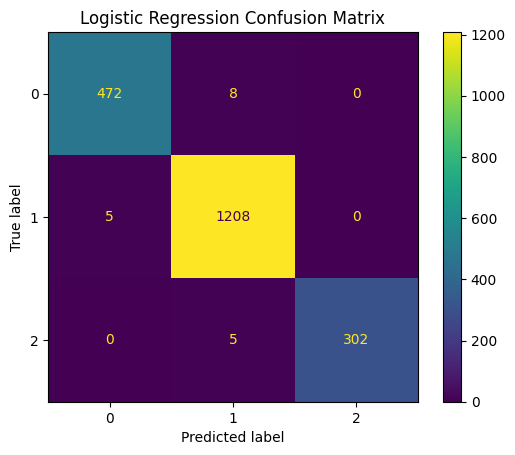

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       480
           1       0.99      1.00      0.99      1213
           2       1.00      0.98      0.99       307

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7335


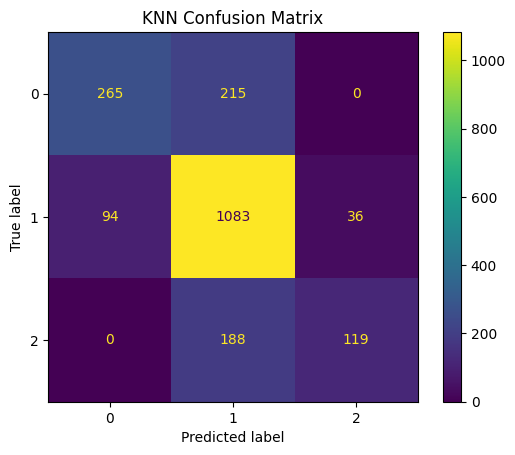

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)

plt.title("KNN Confusion Matrix")
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.74      0.55      0.63       480
           1       0.73      0.89      0.80      1213
           2       0.77      0.39      0.52       307

    accuracy                           0.73      2000
   macro avg       0.74      0.61      0.65      2000
weighted avg       0.74      0.73      0.72      2000



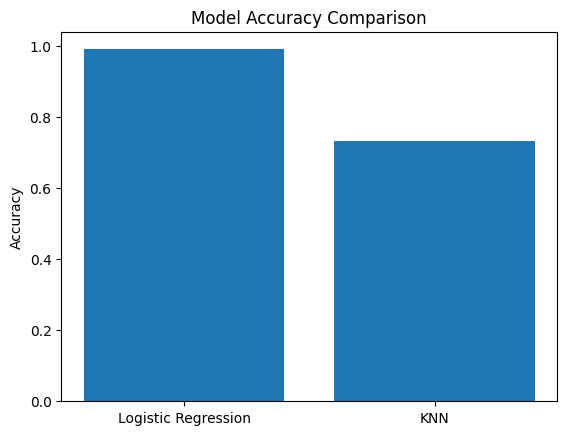

In [30]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "KNN"]
accuracies = [log_accuracy, knn_accuracy]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [31]:
import pandas as pd

importance = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

,0
mental_health_score,0.184625
purpose_Socializing,0.079062
num_platforms_used,0.078248
primary_platform_TikTok,0.078172
purpose_Education,0.076555
gender_Other,0.060223
screen_time_before_sleep,0.038455
primary_platform_YouTube,0.037321
primary_platform_Snapchat,0.023141
primary_platform_Twitter,0.022158


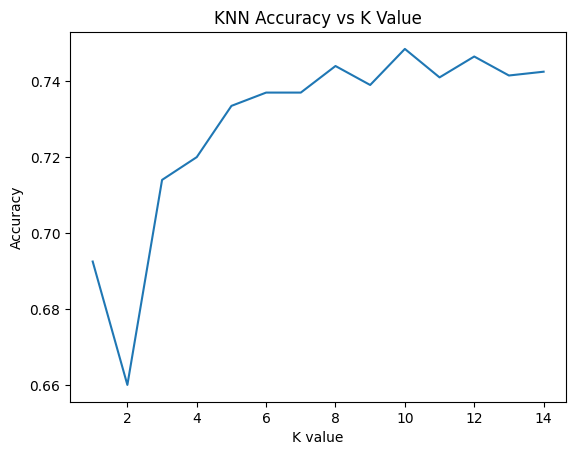

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 15)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    predictions = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, predictions))

plt.plot(k_values, accuracies)
plt.title("KNN Accuracy vs K Value")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.show()

In [33]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (8000, 23)
Testing set shape: (2000, 23)
